# Experimental Holography

`slmsuite` targets _experimental_ holography on physical hardware.
In this example, we show how to connect to a camera and an SLM and
calibrate the transformation between the camera's space and the SLM's $k$-space.

The setup running this notebook (and the notebooks for other examples) is very simple.
A lens is positioned inbetween the camera and SLM with
a distance corresponding to the focal length $f$ from each. Thus, the camera's imaging plane is the
farfield of the SLM (also called Fourier domain or $k$-space of the SLM).

In [1]:
# Header. This is hidden from sphinx with the json metadata:
#   {"nbsphinx":"hidden"}

# ipython configuration (reloads source code automatically and plots inline)
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, sys
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc('image', cmap='inferno')

#### Loading Hardware

**Cameras** and **SLMs** are connected to python by several SDKs, often provided by hardware
vendors. However, these SDKs likewise have several function names and hardware-specific
quirks. Thus, hardware in `slmsuite` is integrated as subclasses of
the abstract classes `.Camera` and `.SLM`.
These subclasses for [cameras](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.hardware.cameras.html) 
and [slms](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.hardware.slms.html)
are effectively wrappers for given SDKs, implemented with standardized methods and
syntax that the rest of `slmsuite` can understand, but  also include quality-of-life
features. 

SLMs that do not have a display SDK are often interfaced to via a virtual
screen, and the `ScreenMirrored` class projects phase onto these.
If you believe your camera or SLM is not supported by the currently available classes, please 
[open a GitHub issue](https://github.com/holodyne/slmsuite/issues) 
or feel free to write an interface yourself using the provided templates!

First, let's load an SLM. 
We're running this notebook with a `Texas Instruments` phase light modulator (PLM), but the notebook can be configured to any
supported SLM or run with virtual hardware.
Future notebooks `try`/`except` physical hardware to fallback to run on virtual hardware if loading fails.
However, we're introducing the syntax for physical hardware loading here, so for clarity 
we use some documentation magic to hide the fallback code in this notebook
(but the code is there if the notebook is loaded opened the docs).

In [2]:
# ======================================== README========================================                        
# ---------------- (This cell is hidden from readthedocs rendering) ---------------------
# If you're reading this, you might have gotten an error from loading physical hardware 
# in the next cell, but that doesn't mean you can't run this notebook! This cell loads 
# virtual hardware. You can proceed to the Simple Holography section.

# Load in virtual hardware classes.
from slmsuite.hardware.slms.simulated import SimulatedSLM
from slmsuite.hardware.cameras.simulated import SimulatedCamera

# Make the SLM and camera.
slm = SimulatedSLM((1358, 800), pitch_um=10.8, wav_um=0.488)
slm.set_source_analytic(sim=True)       # Program the virtual source.
slm.set_source_analytic()               # Don't bother with wavefront calibration, instead just set it to the same source.

cam = SimulatedCamera(slm, (1024, 1024), pitch_um=2.74, gain=50)

# Tie the camera and SLM together with an analytic Fourier calibration.
from slmsuite.hardware.cameraslms import FourierSLM

fs = FourierSLM(cam, slm)
M, b = fs.fourier_calibration_build(
    f_eff=150e3 / slm.wav_um,           # f_eff of 150 mm normalized to wavelength.
    theta=5 * np.pi / 180,              # Slight rotation for fun.
)
fs.fourier_calibrate_analytic(M, b);

[INF] 17:26:13 SimulatedSLM Initialized SimulatedSLM.
[INF] 17:26:13 SimulatedCamera Initialized SimulatedCamera.
[INF] 17:26:13 Hologram Initialized Hologram.
[INF] 17:26:13 SimulatedCamera-SimulatedSLM Initialized FourierSLM.
[INF] 17:26:13 Hologram #2 Initialized Hologram.


We can detect connected physical hardware via slmsuite interfaces using the `.info()` static method.

In [3]:
from slmsuite.hardware.slms.texasinstruments import PLM
PLM.info();

Display Positions:
#,  Position,  Identifier
0,  x=0, y=0, width=1920, height=1080 (main),  DISPLAY#GSM5C6A#5&4c0ed3&1&UID4352
1,  x=4636, y=0, width=2716, height=1600,  DISPLAY#DLP03C9#5&4c0ed3&1&UID4355
2,  x=1920, y=0, width=2716, height=1600,  DISPLAY#DLP03C9#5&4c0ed3&1&UID4353


Since our SLM is a `ScreenMirrored` subclass (i.e., the SLM mirrors a virtual monitor on the local computer), 
the `.info()` method returns information about the local monitors. 
In our case, Display 0 is the main computer display, which we're using to interact with this notebook.
The other two displays are both PLMs, and we have previously determined that Display 2 is the PLM we want to interface with for this tutorial.
The USB-related parameters are PLM-specific, but other SLMs can have similar subtlety.

In [4]:
slm = PLM(
    'p67',
    display_number=2,
    configure_usb=True,
    usb_device_number=1,
    wav_um=0.488,
    settle_time_s=0.05,
    name='PLM',
)

[INF] 17:26:14 PLM Initialized PLM on display 2.


We've given the class other important information:

- The `model_name` of PLM we're using, `'p67'`, which loads the correct pixel size, resolution, and device look-up table (LUT; a model-specific mapping between input pixel display values and output displacements/phase shifts).
- The wavelength (in microns) `wav_um` used in our system, here a 488 nm laser. Combined with the pixel size, this calibrates unit conversions needed to run the SLM.
- The settle time in seconds of the SLM `settle_time_s`. This is a blocking delay such that any follow on commands (e.g., imaging) take place after the phase shifts have stabilized (i.e., beyond the `1/e` response time). Settle time is also device dependent; for example, an LCOS SLMs which have a longer response time than PLMs. Here, we set `settle_time_s` $\gg 1/60\text{ Hz}$ to account for the PLM display's frame rate when controlled over DisplayPort.

Together, this gives `slmsuite` all the information needed to run the SLM.
With `ScreenMirrored`, we can also confirm that the display is now used by checking  `.info()` again, as it is labeled with `(has ScreenMirrored)`.

In [5]:
PLM.info();

Display Positions:
#,  Position,  Identifier
0,  x=0, y=0, width=1920, height=1080 (main),  DISPLAY#GSM5C6A#5&4c0ed3&1&UID4352
1,  x=4636, y=0, width=2716, height=1600,  DISPLAY#DLP03C9#5&4c0ed3&1&UID4355
2,  x=1920, y=0, width=2716, height=1600 (has ScreenMirrored),  DISPLAY#DLP03C9#5&4c0ed3&1&UID4353


Next, let's load the camera. We're running this notebook with a `FLIR` camera. We can again find connected hardware with the `.info()` static method.

In [6]:
from slmsuite.hardware.cameras.flir import FLIR
FLIR.info();

22562470 ('Blackfly S BFS-U3-161S7M')


We want the `"22562470"` serial.

In [7]:
cam = FLIR(
    serial="22562470",
    pitch_um=2.74, 
    bitdepth=12,
    name="FLIR Cam"
)

[INF] 17:26:19 FLIR Cam Initialized FLIR.


Hardware sometimes needs some level of preconfiguration to get into a state ready for experiments.
`slmsuite` hardware objects implement holography-relevant functionality as required methods with a defined signature (e.g. `set_phase`, `get_image`, `set_exposure`, etc).
For editing specific or unique attributes (e.g. triggering, pixel clock, camera mode, etc), the hardware object can usually also be accessed directly via `cam.cam`.
In this case, we want to crop the window of interest (WOI) to the center region via `set_woi`.

In [8]:
cam.set_woi((1024, 1024));  # set_woi accepts (x0, w, y0, h) format, but passing (w, h) will automatically compute (x0, y0) to center the WOI.

[WRN] 17:26:19 FLIR Cam Attempted to set WOI to (2148, 1024, 1004, 1024), but realized (2148, 1024, 1000, 1024).


Lastly, we'll make a [class for our composite optical system](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.hardware.cameraslms.FourierSLM.html#slmsuite.hardware.cameraslms.FourierSLM), a `FourierSLM`
consisting of the camera and the SLM. We'll also load a few calibrations to make the SLM perform as close to ideal as possible.

These include a previously-measured
[LUT calibration](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.hardware.cameraslms.FourierSLM.html#slmsuite.hardware.cameraslms.FourierSLM.pixel_calibrate)
and
[wavefront calibration](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.hardware.cameraslms.FourierSLM.html#slmsuite.hardware.cameraslms.FourierSLM.wavefront_calibrate).
Both calibrations will be discussed in a follow-on tutorial, so for now just know that `slmsuite` offers simple ways to characterize and calibrate SLMs to achieve the near-ideal performance illustrated in this notebook.

Finally, the `try`/`except` block is simply for users who may be running this notebook using simulated hardware (hidden from the online notebook rendering but accessible by downloading this notebook) instead of a dedicated setup mirroring ours.

[INF] 17:26:19 FLIR Cam-PLM Initialized FourierSLM.
[INF] 17:26:19 FLIR Cam-PLM Loaded 'pixel' calibration from 'slm2_pixel_calibration_1-5V.h5'.
[INF] 17:26:19 FLIR Cam-PLM Loaded 'wavefront' calibration from 'slm2_superpixel_calibration_offset=0-25_wav=488.h5'.
[WRN] 17:26:19 FLIR Cam-PLM remove_background is enabled and a noise floor was detected; removing this background (4.2% of the average normalization).


smooth: 100%|██████████| 16/16 [00:00<00:00, 31.95it/s]


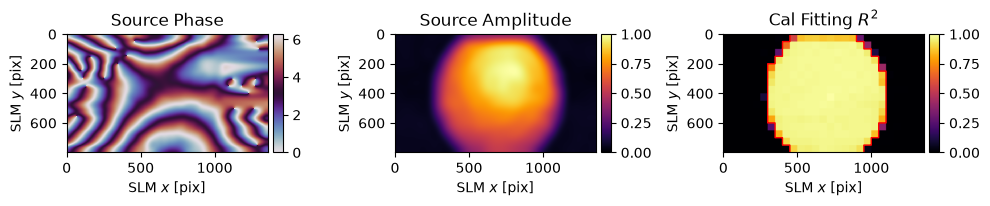

array([[255,   0,   0, ..., 255, 255,   0],
       [  0, 255, 255, ...,   0, 255,   0],
       [255, 255, 255, ..., 255, 255,   0],
       ...,
       [  0, 255, 255, ...,   0,   0, 255],
       [255, 255,   0, ..., 255, 255,   0],
       [  0, 255, 255, ...,   0,   0, 255]],
      shape=(1600, 2716), dtype=uint8)

In [9]:
from slmsuite.hardware.cameraslms import FourierSLM
fs = FourierSLM(cam, slm)

# Load pixel calibration (also called LUT or gamma correction).
fs.load_calibration('pixel', 'slm2_pixel_calibration_1-5V.h5')
fs.pixel_calibration_process(plot=False)

# Load wavefront calibration.
fs.load_calibration('wavefront', 'slm2_superpixel_calibration_offset=0-25_wav=488.h5')
fs.wavefront_calibration_superpixel_process(r2_threshold=.5, smooth=True, plot=True)

# We'll also add a blazed grating to the SLM source to roughly center the reflection on our camera.
# This won't be necessary for most setups, but is used here due to some peculiarities of our dual-SLM setup.
from slmsuite.holography import toolbox
slm.source['phase'] += toolbox.phase.blaze(slm, toolbox.convert_vector((0.28,-0.01), from_units="freq", to_units="norm", hardware=fs))
slm.set_phase(None)

#### Simple Holography

Let's start out with the simplest phase pattern possible: no pattern! We 
[set](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.hardware.slms.slm.SLM.html#slmsuite.hardware.slms.slm.SLM.set_phase) 
a flat phase $\phi(\vec{x}) = 0\pi$ to the SLM with `.set_phase()`.

In [10]:
phase = np.zeros(slm.shape)
slm.set_phase(phase, settle=True);  # slm.set_phase(None, settle=True) is equivalent to this.

Great. Let's [take a look](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.hardware.cameras.camera.Camera.html#slmsuite.hardware.cameras.camera.Camera.get_image)
at the result in our camera with `.get_image()`. We'll also set the exposure to an appropriate value using the autoexposure features.

[INF] 17:26:21 FLIR Cam Autoexpose: 1.07e-04 s - 1861/4095


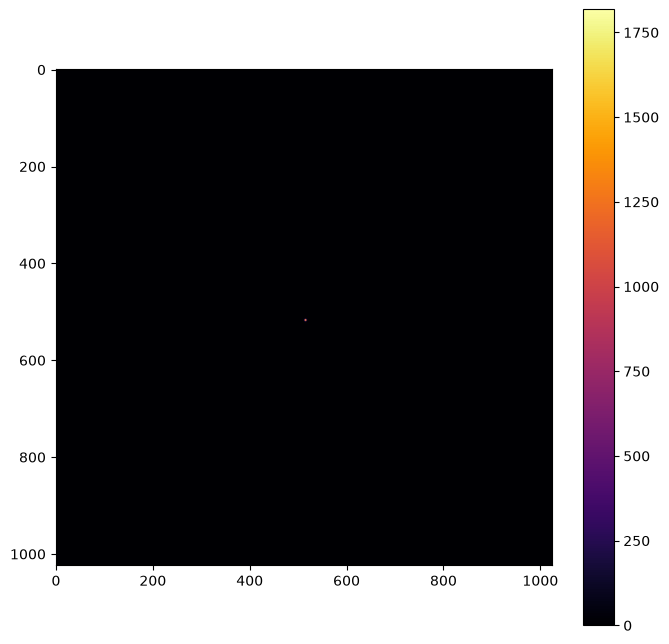

In [11]:
single_spot_exposure_s = cam.autoexpose(set_fraction=0.5)      # Target peak intensity to be 50% of saturation.

# Grab an image from the camera.
img = cam.get_image()

# Plot the result (manually)
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.colorbar()
plt.show()

assert np.max(img) > cam.bitresolution / 10, "The image is too dark. Did something go wrong with autoexposure?"

We can also create a similar plot of the image with a simple call to `.plot()`, 
also taking advantage of the `limits=.25` parameter to zoom in on the center 25% of the field of view:

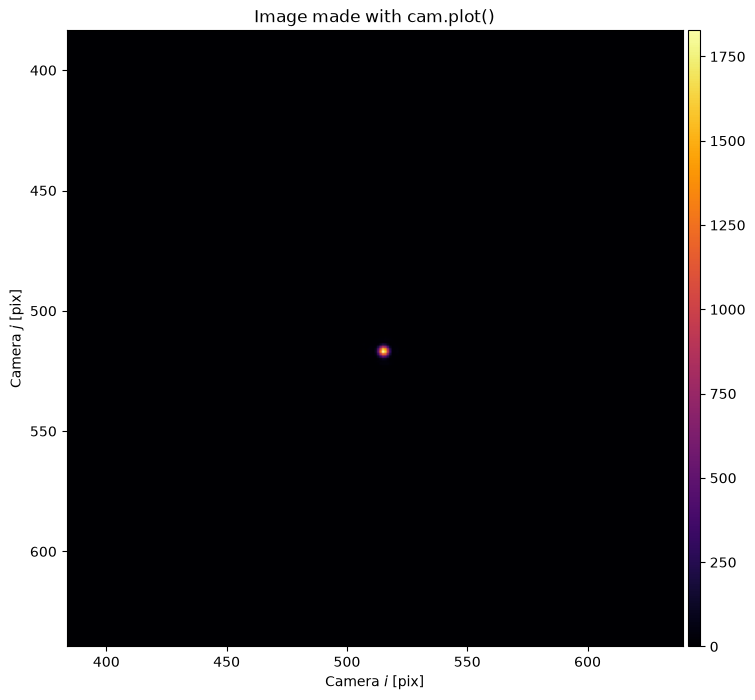

In [12]:
cam.plot(limits=.25, title="Image made with cam.plot()");

We see a spot corresponding to the zero-th order diffraction peak (i.e. undiffracted
because no phase is written). This spot is focused near the center of our camera.
Next, we'll move the laser spot by applying a 
[blazed grating](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.holography.toolbox.phase.blaze.html#slmsuite.holography.toolbox.phase.blaze)
to the SLM using a helper function from our `toolbox`. This blazed grating has a Fourier
spectrum shifted from the origin, so naturally applying this pattern to the SLM will
produce a shifted result in the farfield, i.e. in the plane of the camera. Note that the
phase pattern is in units of phase (units of $2\pi$). This is then translated into the
integer data that is actually displayed on the SLM (see `.set_phase()` or `._phase2gray()`).
If one passes integer `phase` to the SLM in `.set_phase()`, then this data is displayed
directly, but any float data is interpreted as a phase. As an additional subtlety, most
SLMs have an "increasing integer value, increasing voltage, decreasing phase"
convention, so any passed phase is inverted in sign before displaying to have the
correct convention.

Many common phases patterns are available in the `slmsuite.holography.toolbox.phase`
module, alongside `blaze()`. 
See the [Structured Light Example](https://slmsuite.holodyne.com/en/latest/_examples/structured_light.html) for more information
such as the behavior of `grid=`, which pulls wavelength and pixel pitch information from the SLM to blaze accurately.
We're going to be `.set_phase()`ing `.get_image()`ing a couple more times in
this notebook, so we'll use the helper function `fs.plot()` to simplify plotting. One can
also use `cam.plot()` and `slm.plot()` to plot the phase and amplitudes alone.

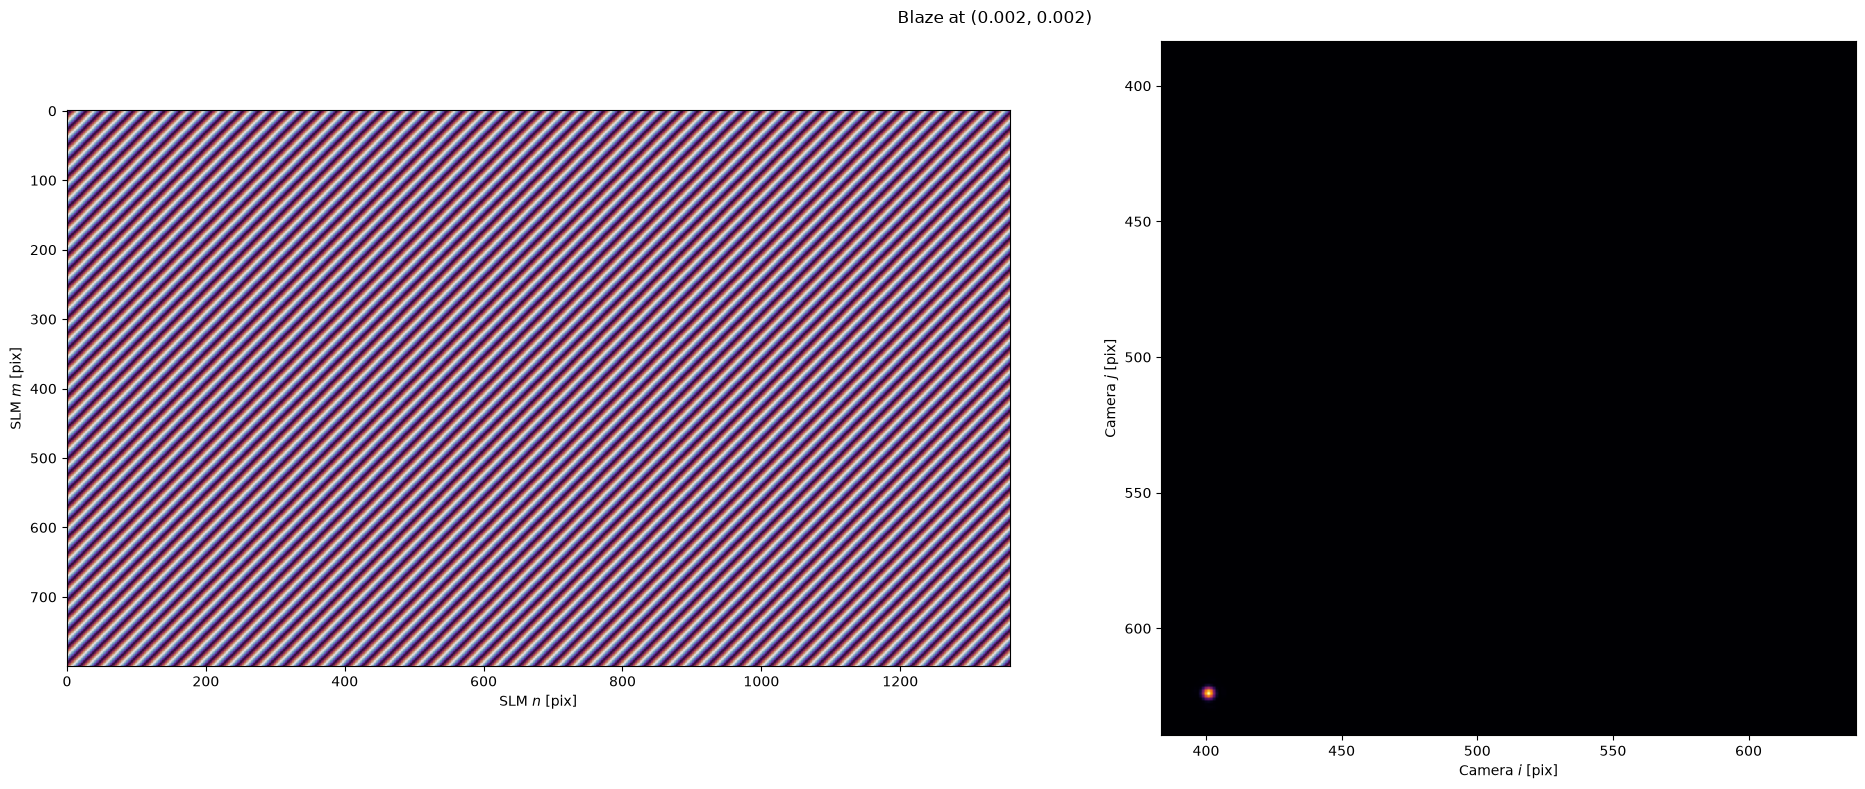

In [13]:
from slmsuite.holography import toolbox

vector = (.002, .002)                                       # Radians (== normalized units kx/k).
blaze_phase = toolbox.phase.blaze(grid=slm, vector=vector)  # Phase in units of 2pi.

fs.plot(blaze_phase, title="Blaze at {}".format(vector), cam_limits=.25);

Notice that the spot is now shifted. But what units does `vector` have? The default blaze units in `slmsuite` (`"norm"`) are normalized $k_x/k$ units, which are equivalent to radians in the small angle approximation. To get a better handle on what `vector = (.002, .002)` means, we can 
[print](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.holography.toolbox.print_blaze_conversions.html#slmsuite.holography.toolbox.print_blaze_conversions)
the equivalent vectors converted to supported units with `toolbox.print_blaze_conversions()` (n.b. `"ij"` is not yet calibrated so it cannot be converted).

In [14]:
toolbox.print_blaze_conversions(vector=(.002, .002), from_units="norm", hardware=fs)

'rad' : [0.002 0.002]
'mrad' : [2. 2.]
'deg' : [0.11459156 0.11459156]
'norm' : [0.002 0.002]
'kxy' : [0.002 0.002]
'knm' : [739.10819672 435.40983607]
'freq' : [0.0442623 0.0442623]
'lpmm' : [4.09836066 4.09836066]
'zernike' : [218.97599324 218.97599324]
[WRN] 17:26:22 holography.toolbox A Fourier-calibrated CameraSLM must be passed as hardware for conversion 'norm' to 'ij'
'ij' : [nan nan]
[WRN] 17:26:22 holography.toolbox A Fourier-calibrated CameraSLM must be passed as hardware for conversion 'norm' to 'ijraw'
'ijraw' : [nan nan]
[WRN] 17:26:22 holography.toolbox A Fourier-calibrated CameraSLM must be passed as hardware for conversion 'norm' to 'm'
'm' : [nan nan]
[WRN] 17:26:22 holography.toolbox A Fourier-calibrated CameraSLM must be passed as hardware for conversion 'norm' to 'cm'
'cm' : [nan nan]
[WRN] 17:26:22 holography.toolbox A Fourier-calibrated CameraSLM must be passed as hardware for conversion 'norm' to 'mm'
'mm' : [nan nan]
[WRN] 17:26:22 holography.toolbox A Fourier-c

So we're diffracting light by an angle of two milliradians or a tenth of a degree.
You can read more about all the units in the [documentation](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.holography.toolbox.convert_vector.html#slmsuite.holography.toolbox.convert_vector).
Notice that some of the units are `nan` (and that we are warned about this). This is because we haven't yet calibrated some needed conversions related to the
relationship between the SLM's $k$-space and the camera's pixel space, but more on that next section.

This function wraps `toolbox.convert_vector()` which handles arbitrary unit conversions. Let's try it out by diffracting light at .2 degrees in the $x$ and $y$ directions.

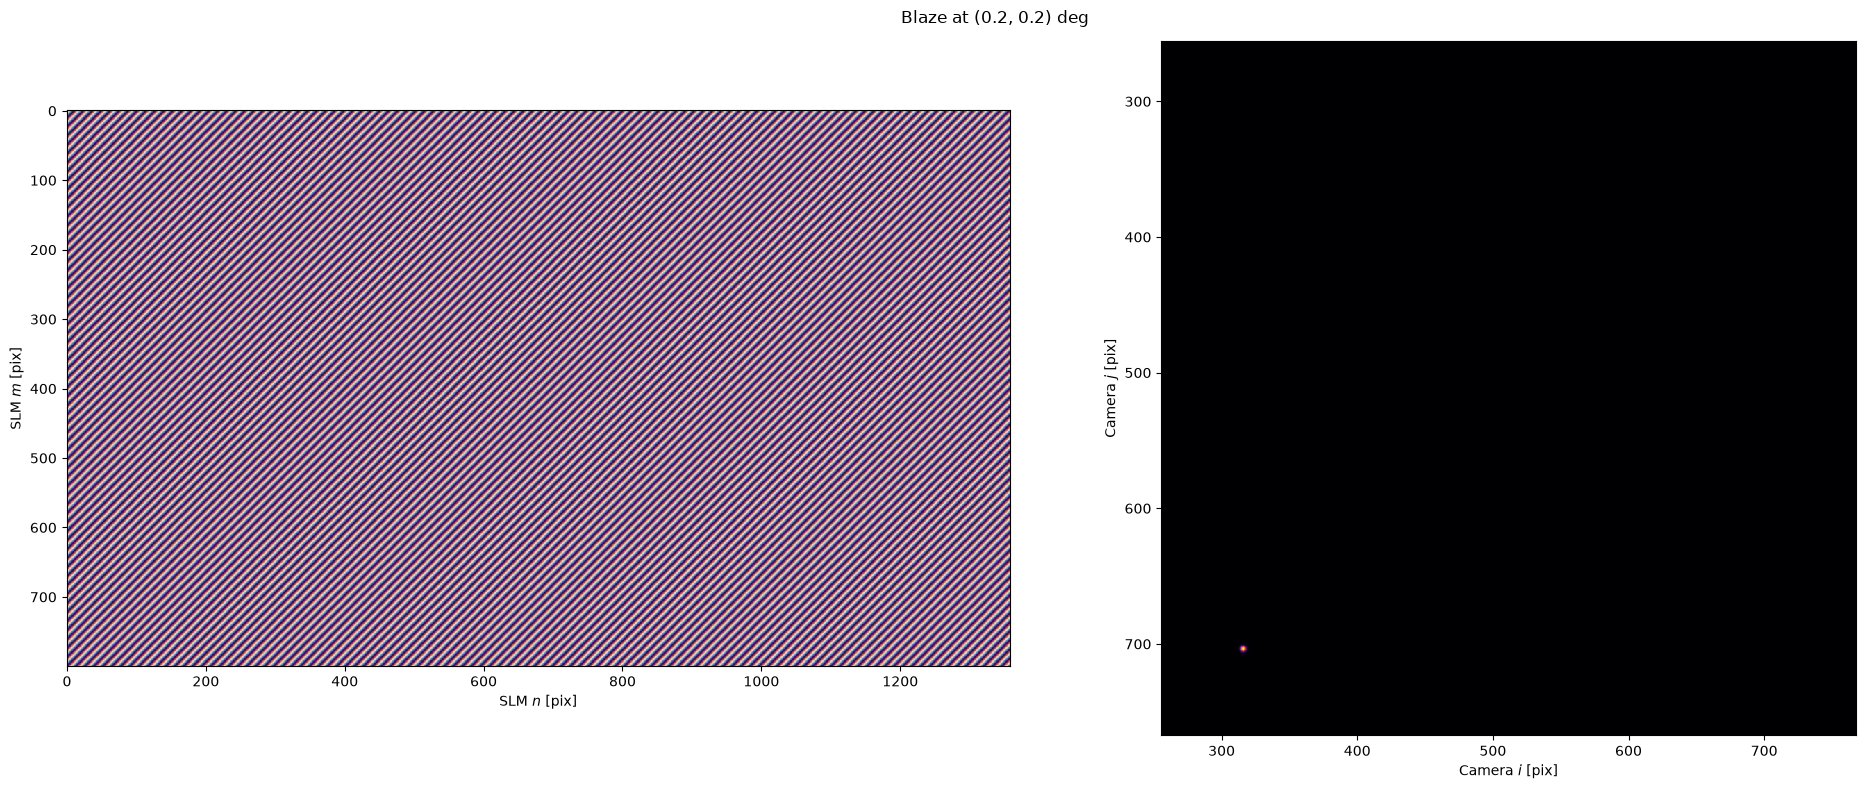

In [15]:
# Get .2 degrees in normalized units.
vector_deg = (.2, .2)
vector = toolbox.convert_vector(vector_deg, from_units="deg", to_units="norm")

# Get the phase for the new vector
blaze_phase = toolbox.phase.blaze(grid=slm, vector=vector)

fs.plot(blaze_phase, title="Blaze at {} deg".format(vector_deg), cam_limits=.5);

All this is good fun, but let's say we wanted our spot right at pixel `(500, 700)`. We could iterate by guessing and checking successive `vectors`, but that seems boring and non-pythonic. Instead, we will calibrate a transformation between the $k$-space of the SLM and the space of the camera using features built-in to `slmsuite`.

#### Fourier Calibration

Calibration is simple, just run a built-in function `.fourier_calibrate()` to 1) generate and 2) fit a grid of spots (with known $k$-space coordinates) with an affine transformation to the space of the camera. This grid is generated using the same holography algorithms we explored in the [computational holography](https://slmsuite.holodyne.com/en/latest/_examples/computational_holography.html) tutorial. We'll come back to experimental implementations of these shortly; for now, care must be taken to choose:

 - A camera exposure such that spots are prominent,
 - A pitch and shape of the array which are visually resolvable.

Note that the default array units are in `"knm"` space, or the 
[computational space of holography](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.holography.algorithms.html). 
Read more about this in later examples.

[INF] 17:26:23 Fourier Grid Initialized SpotHologram.


Fourier Grid: 100%|██████████| 10/10 [00:00<00:00, 406.39it/s]


[INF] 17:26:23 FLIR Cam Autoexpose: 2.55e-02 s - 2015/4095


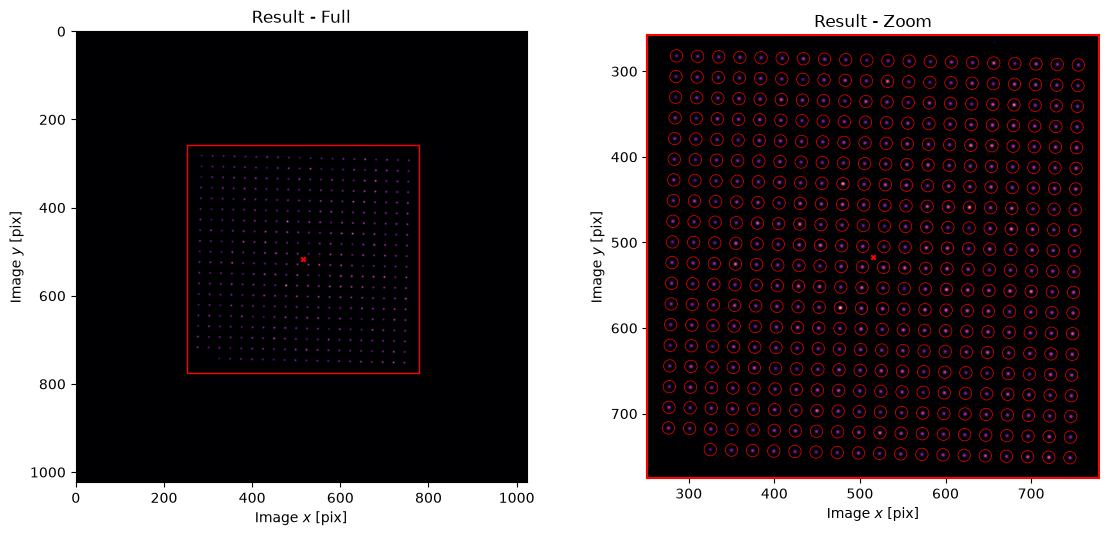

In [16]:
fs.fourier_calibrate(
    array_shape=20,                         # Size of the calibration grid (Nx, Ny) [#]
    array_pitch=20,                         # Pitch of the calibration grid (x, y) [knm]
    autoexpose=True,
    plot=True
);

Notice that there are two missing spots from the array. This is a parity check to make sure the calibration is flipped in the correct direction.

The result of this process is the transformation

$\vec{x} = M \cdot (\vec{k} - \vec{a}) + \vec{b}$

where $\vec{x}$ is in units of camera pixels and $\vec{k}$ is in units of normalized $k$-space. We can view the result in the `"fourier"` variable.

In [17]:
fs.calibrations["fourier"]

{'M': array([[-56009.14975152,  -1173.56428234],
        [ -1266.45934449,  54737.45789643]]),
 'b': array([[2663.49520998],
        [1516.73685122]]),
 'a': array([[0.],
        [0.]]),
 'array': {'array_shape': [20, 20],
  'array_pitch': [20, 20],
  'array_center': array([ 8.76122968e-21, -1.40179675e-19]),
  'autoexpose': True,
  'autofocus': False},
 '__version__': '0.5.0',
 '__time__': '2026-10-04 17:26:24.162270',
 '__timestamp__': 1791149184.16227,
 '__meta__': {'__class__': 'FourierSLM',
  'name': 'FLIR Cam-PLM',
  'cam': {'__class__': 'FLIR',
   'name': 'FLIR Cam',
   'shape': (1024, 1024),
   'bitdepth': 12,
   'bitresolution': 4096,
   'pitch_um': array([2.74, 2.74]),
   'exposure_s': 0.02553,
   'exposure_bounds_s': (2.9e-05, 30.00001),
   'averaging': None,
   'hdr': None,
   'woi': (2148, 1024, 1000, 1024),
   'binning': (1, 1),
   '_shape': (3032, 5320),
   '_software_woi': False,
   '_software_binning': False},
  'slm': {'__class__': 'PLM',
   'name': 'PLM',
   'shape':

Now let's use this calibration to achieve our goal of `(500, 700)`. We can find the blaze vector $\vec{k}$ (in normalized units) corresponding to the desired pixel $\vec{x}$ using our calibration.

In [18]:
vector_ij = (500, 700)
vector_kxy = fs.ijcam_to_kxyslm(vector_ij)
print(vector_kxy)

[[0.0002064 ]
 [0.00335281]]


Now let's check this result:

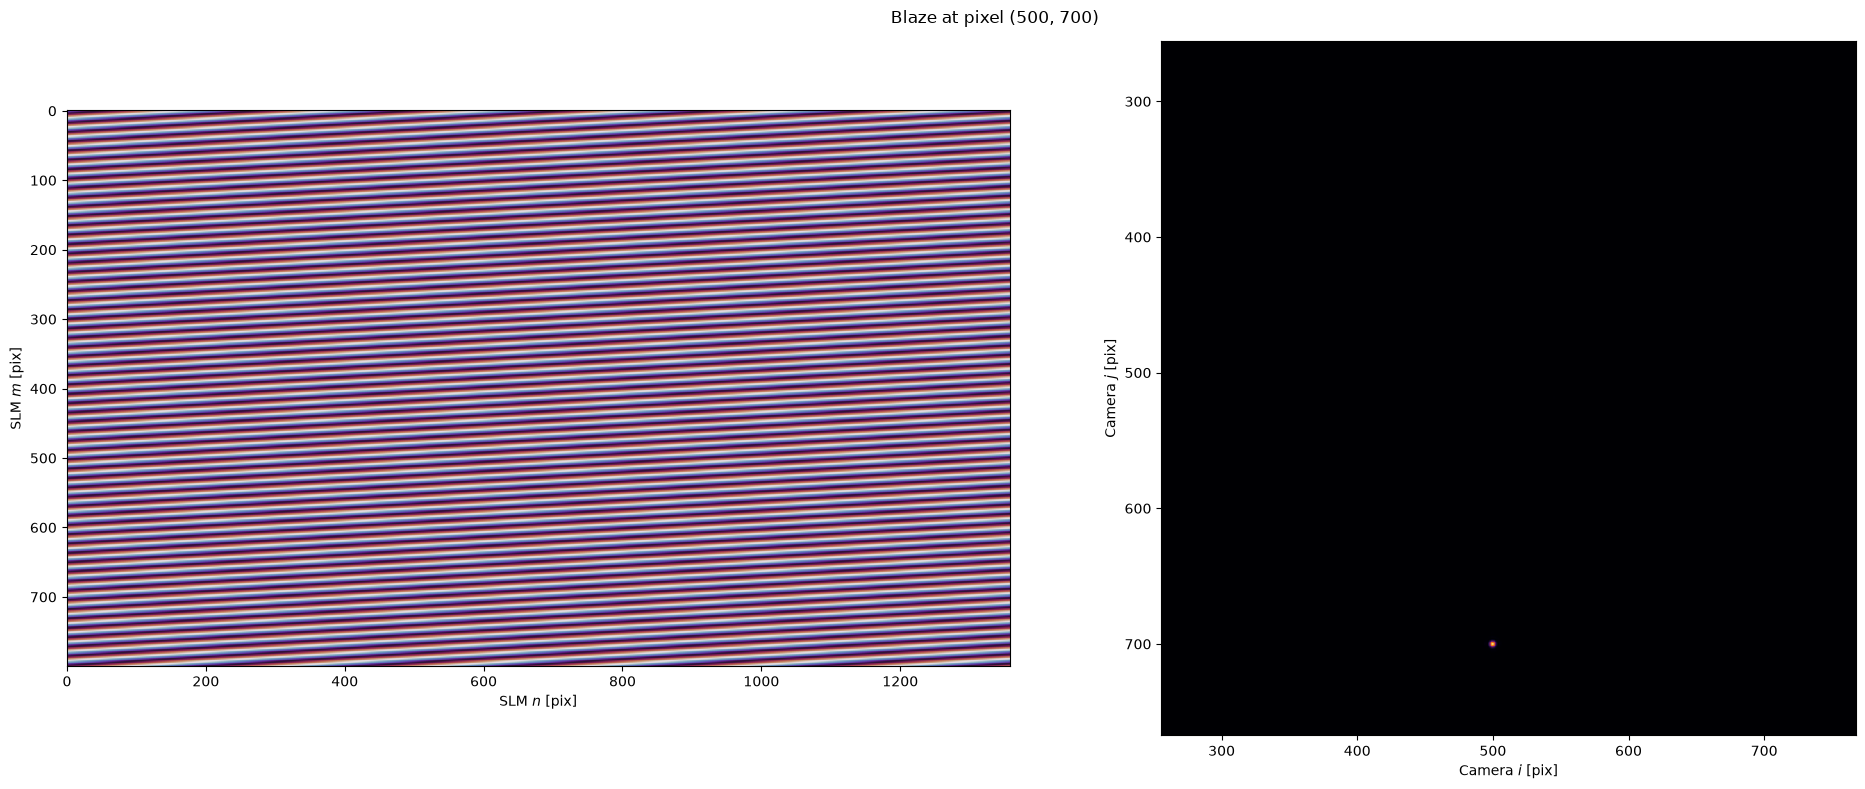

In [19]:
blaze_phase = toolbox.phase.blaze(grid=slm, vector=vector_kxy)

cam.set_exposure(single_spot_exposure_s)
fs.plot(blaze_phase, title=f"Blaze at pixel {vector_ij}", cam_limits=.5)

img = cam.get_image()
expected_area = img[(slice(vector_ij[1]-10, vector_ij[1]+10), slice(vector_ij[0]-10, vector_ij[0]+10))]
assert np.mean(expected_area) > np.mean(img), "Make sure most of the power is in the expected area."

Let's also go back to `print_blaze_conversions`. With the extra information from Fourier calibration 
stored in `fs` (now passed as `hardware=`), all the units are now filled out.

In [20]:
toolbox.print_blaze_conversions(vector=vector_ij, from_units="ij", hardware=fs)

'rad' : [0.0002064  0.00335281]
'mrad' : [0.20640318 3.35281464]
'deg' : [0.01182603 0.19210213]
'norm' : [0.0002064  0.00335281]
'kxy' : [0.0002064  0.00335281]
'knm' : [685.2032614  459.36130832]
'freq' : [0.00456794 0.07420164]
'lpmm' : [0.42295733 6.8705218 ]
'zernike' : [ 22.5986704  367.09295761]
'ij' : [500. 700.]
'ijraw' : [2648. 1700.]
'm' : [0.00137  0.001918]
'cm' : [0.137  0.1918]
'mm' : [1.37  1.918]
'um' : [1370. 1918.]
'nm' : [1370000. 1918000.]
'mag_m' : [0.00137  0.001918]
'mag_cm' : [0.137  0.1918]
'mag_mm' : [1.37  1.918]
'mag_um' : [1370. 1918.]
'mag_nm' : [1370000. 1918000.]


#### Spot Holography

The previous examples considered blazing light in one direction towards one point, but what if we want to generate patterns with many spots? Of course, this isn't as simple as adding the blaze phase patterns for $\vec{k}_1$ and $\vec{k}_2$, as this would just blaze light along $\vec{k} = \vec{k}_1 + \vec{k}_2$. Things are more complicated. This example will show how to generate `SpotHologram`s with `slmsuite`.



#### A Square Array and `take`

Let's consider a case where we want to fill part of our camera's space with a square array of spots, spaced with a pitch of 100 pixels.

[ 50 100 150 200 250 300 350 400 450 500 550 600 650 700 750 800 850 900
 950]


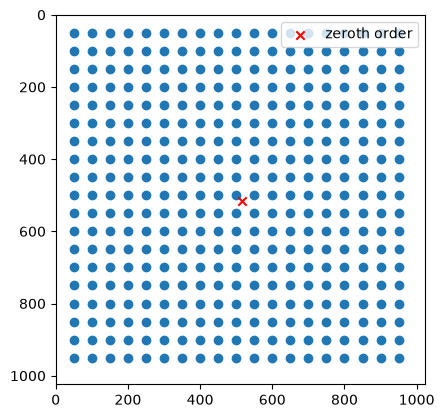

In [21]:
# Get the coordinates for one edge
xlist = np.arange(50, min(fs.cam.shape)-50, 50)                      
print(xlist)

# Make an array of points in a grid
xgrid, ygrid = np.meshgrid(xlist, xlist)
square = np.vstack((xgrid.ravel(), ygrid.ravel()))                  

# Plot the points
plt.scatter(square[0,:], square[1,:])                               
plt.scatter(*fs.zeroth_order_ij.ravel(), marker="x", c="r", label="zeroth order")
plt.xlim([0, fs.cam.shape[1]]); plt.ylim([fs.cam.shape[0], 0])
plt.gca().set_aspect("equal"); plt.legend()
plt.show()

Making a hologram is simple. we initialize a hologram with a computational space of shape `(2048, 2048)`. This shape just has to be larger than the SLM shape, and should ideally consist of powers of two. We provide the points in the `"ij"` basis of our camera's pixels, made possible by the Fourier calibration passed via our `FourierSLM` named `fs`.

In [22]:
from slmsuite.holography.algorithms import SpotHologram
hologram = SpotHologram(shape=(2048, 2048), spot_vectors=square, basis='ij', cameraslm=fs)

[INF] 17:26:24 SpotHologram Initialized SpotHologram.


This initialization only constructs data structures, but does not conduct optimization.

We can first plot the target amplitudes at desired locations in the `"knm"` basis, which is needed to apply discrete Fourier transforms. Our Fourier calibration also shows us how our camera's field of view (in yellow) compares to the size of the computational space.

Next, we plot the amplitudes resulting from the initial conditions of optimization (random phase). This just looks like noise, as expected.

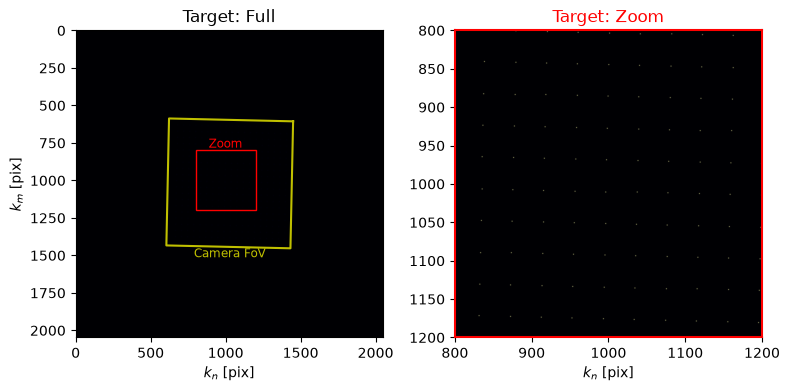

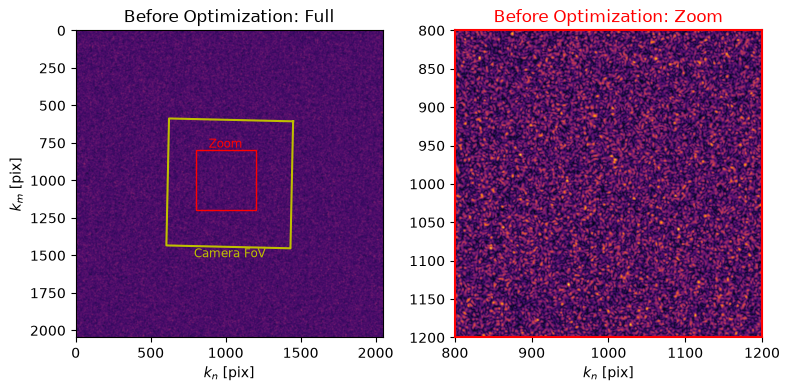

In [23]:
limits = [[800, 1200], [800, 1200]]
hologram.plot_farfield(hologram.target,  limits=limits, title="Target")
hologram.plot_farfield(limits=limits, title="Before Optimization");

This randomness won't last. We quickly take 50 iterations of optimization towards our target. Here, we use weighted [Gerchberg-Saxton](https://en.wikipedia.org/wiki/Gerchberg%E2%80%93Saxton_algorithm)-type algorithms to iteratively hone the nearfield phase pattern to produce the desired farfield at the camera. 

100%|██████████| 50/50 [00:00<00:00, 145.74it/s]


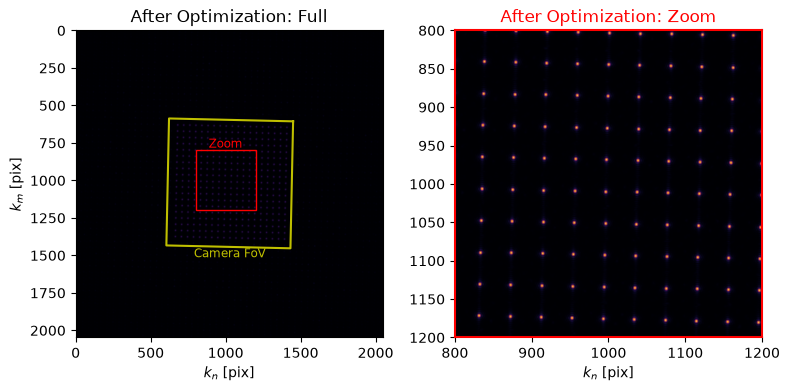

In [24]:
cam.set_exposure(single_spot_exposure_s * square.shape[1])     # Increase exposure to account for array size.
hologram.optimize('WGS-Kim', feedback='computational_spot', stat_groups=['computational_spot'], maxiter=50)
hologram.plot_farfield(limits=limits, title="After Optimization");

Now the computed result of our optimized hologram roughly matches the target. The phase that generates this amplitude result in the farfield is plotted below. The amplitude pattern is an estimate of the real nearfield amplitude measured via wavefront calibration. Note that we plot both the system padded to the `(2048, 2048)` shape of the computational space (used during optimization) and the system cropped to the shape of the SLM (used in practice).

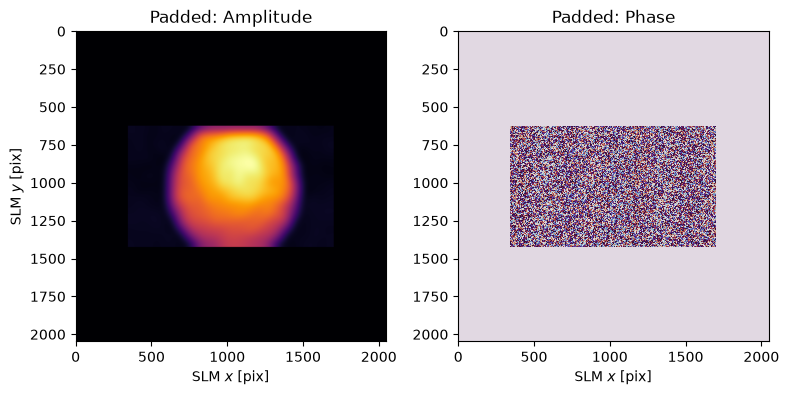

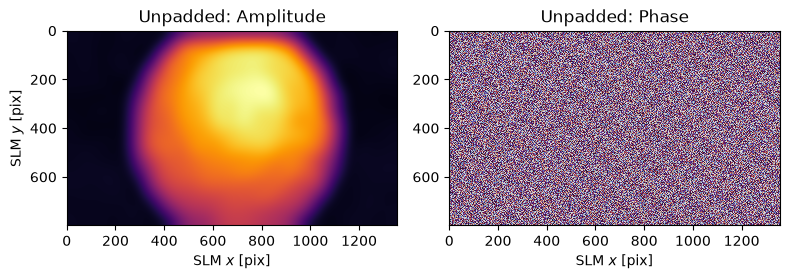

In [25]:
hologram.plot_nearfield(title="Padded", padded=True)
hologram.plot_nearfield(title="Unpadded")

Let's see how this looks experimentally.

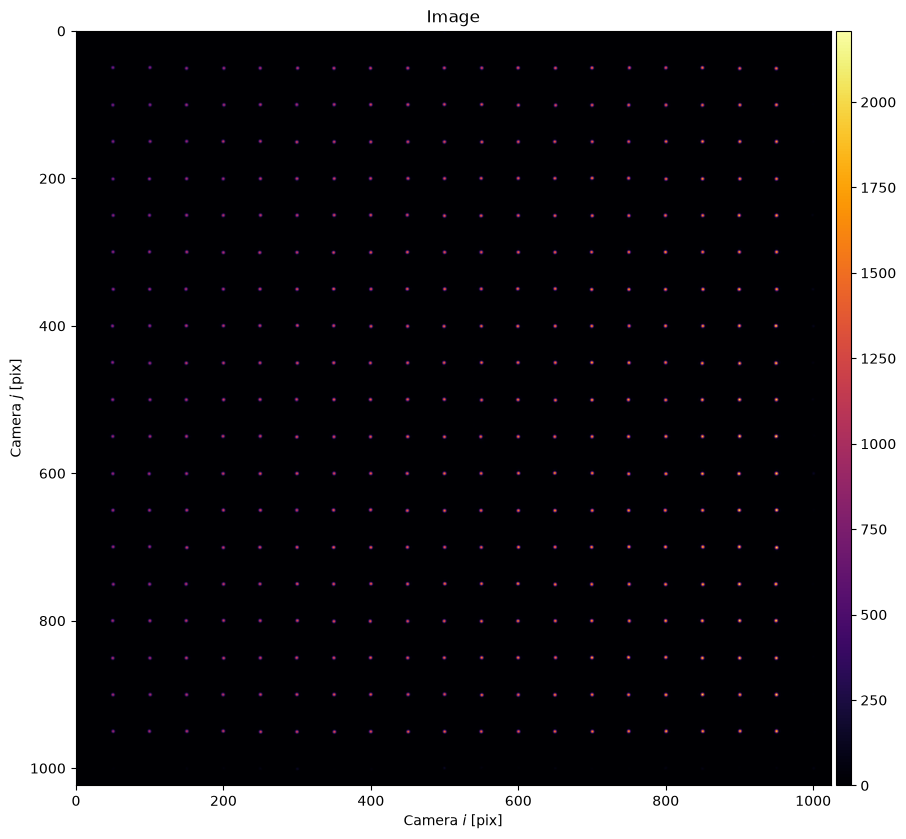

In [26]:
# Write hologram and get an image.
fs.slm.set_phase(hologram.get_phase(), settle=True)                
img = fs.cam.get_image()                                            

plt.figure(figsize=(10,10))
fs.cam.plot(img);

Looks good! We can immediately see that the spots on the left edge of the field of view are less bright, which (when considering the global blaze that we applied when loading the slm) corresponds to reduced SLM diffraction efficiency in these areas. 
Let's `take()` a closer look at this, making use of helper functions in the `analysis` module. 
The function `take()` is very useful to analyze spots. It crops an image into many windows with width `size` around a desired set of `vectors`, in our case, the points at which we expect spots to appear. 
`take()` is written to be efficient, making heavy use of `numpy`/`cupy` parallelism, and has many useful
[options](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.holography.analysis.take.html#slmsuite.holography.analysis.take).

We also plot the regions we took from the image using the `take_plot()` helper function.

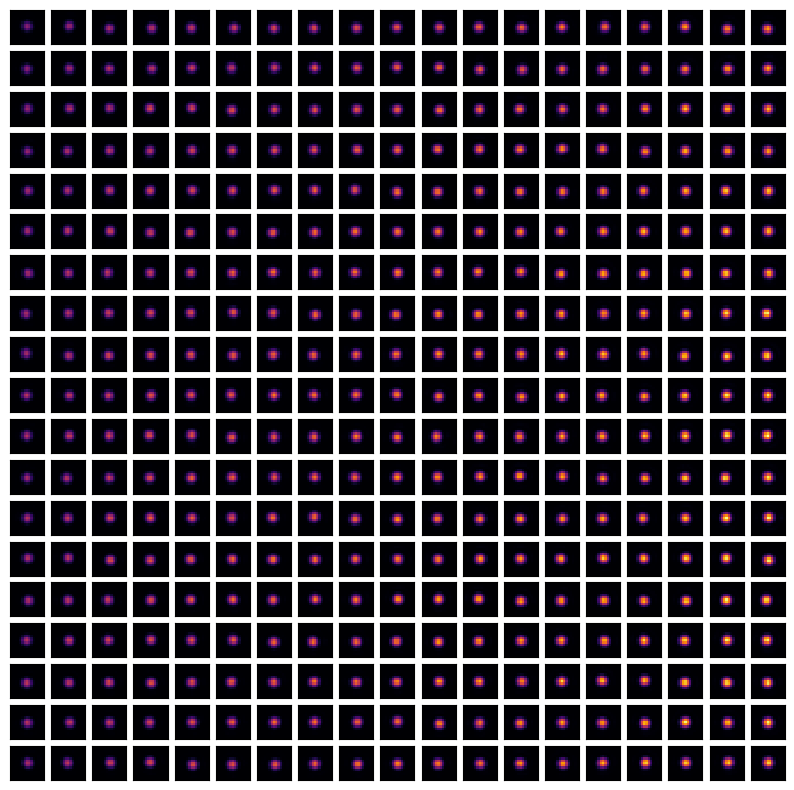

In [27]:
from slmsuite.holography import analysis

subimages = analysis.take(img, vectors=square, size=15)
assert np.mean(subimages) > np.mean(img) / 2, "Make sure the subimages cover most of the power in the image."

analysis.take_plot(subimages, separate_axes=True, figsize=10)

We can quantitatively measure uniformity and other statistics with helper functions operating (in batch) on stacks of images.
Examples include `image_positions()` for centroid measurement and `image_normalization()` for power calculation.

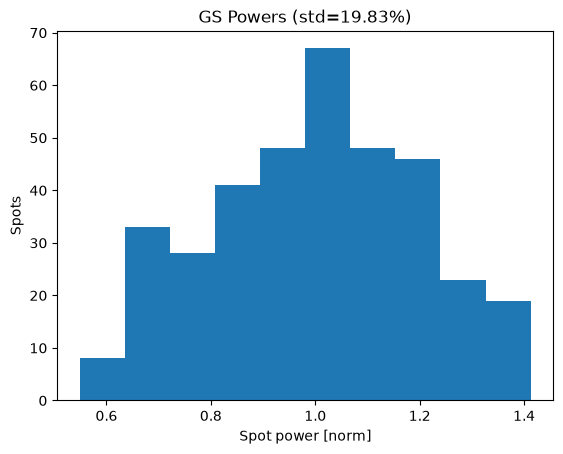

In [28]:
# Quantify uniformity.
powers = analysis.image_normalization(subimages)
powers_norm = powers / np.mean(powers)
powers_norm_std_gs = np.std(powers_norm)

plt.hist(powers_norm)
plt.title("GS Powers (std={:.2f}%)".format(powers_norm_std_gs * 100))
plt.xlabel("Spot power [norm]")
plt.ylabel("Spots")
plt.show()

There's a good amount of variation across the array, some result from diffraction efficiency variations across field of view. In practice, the closer to the edge of the $k$-space one gets, the lower the efficiency due to sampling considerations.
The solution is camera feedback, a focus of `slmsuite` as a package that considers the unification of SLMs and cameras.

#### A Uniform Square Array

We can easily enable camera feedback by using the option to `feedback` upon the power at spots measured by the camera. This is enabled by switching to `"experimental_spot"` (versus `"computational_spot"`) feedback. Since the optimization with experimental feedback is a bit slower (we wait for the SLM to settle and for the camera to grab an image), we precondition our optimization computationally-optimized pattern.

In [29]:
hologram = SpotHologram(shape=(2048, 2048), spot_vectors=square, basis='ij', cameraslm=fs)

# Precondition computationally.
hologram.optimize(
    'WGS-Leonardo',
    maxiter=10,
    feedback='computational_spot',
    stat_groups=['computational_spot']
)

# Write hologram and center
slm.set_phase(hologram.get_phase(), settle=True) 
hologram.refine_offset(img=cam.get_image(), force_affine=False, plot=False)

# Hone the result with experimental feedback.
hologram.spot_integration_width_ij = 15
hologram.optimize(
    'WGS-Kim',
    maxiter=20,
    feedback='experimental_spot',
    stat_groups=['experimental_spot'],
    fix_phase_iteration = 20
)

[INF] 17:26:29 SpotHologram #2 Initialized SpotHologram.


100%|██████████| 10/10 [00:00<00:00, 129.64it/s]


[INF] 17:26:29 SpotHologram #2 Refine offset: avergage shift 0.000106 kxy distance.
[INF] 17:26:29 SpotHologram #2 Refine offset: average shift 4.803542 knm pixel distance.


100%|██████████| 20/20 [00:05<00:00,  3.68it/s]


And let's take a look at our result.

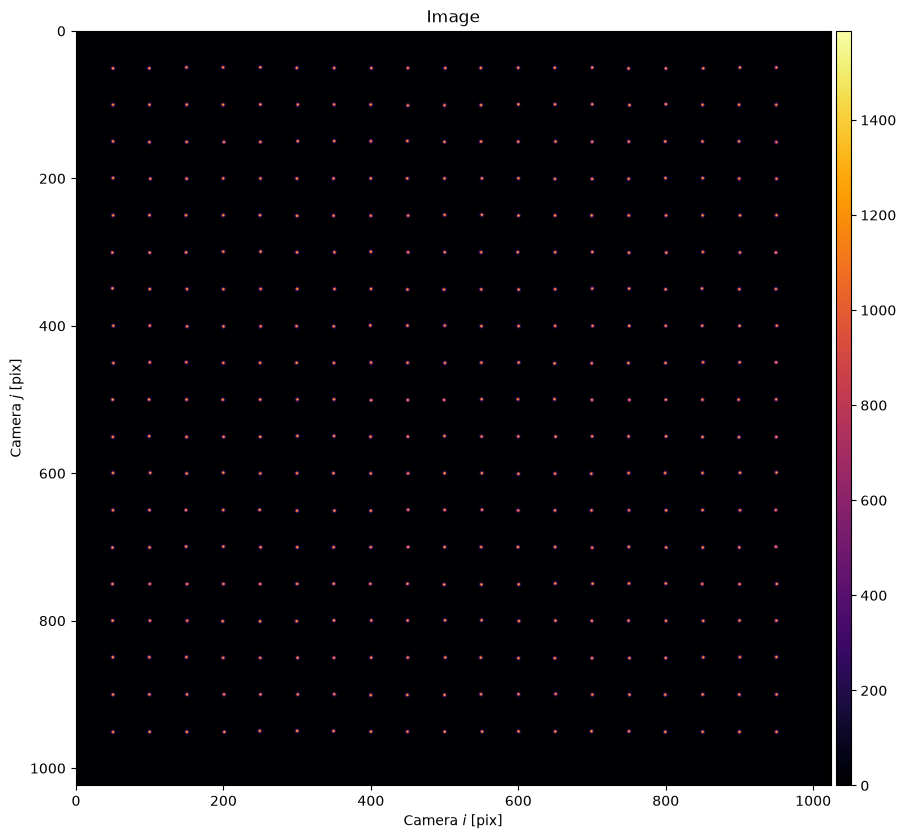

In [30]:
# Grab image (this time we don't have to .set_phase() to the SLM, because the
# optimization did this already).
img = fs.cam.get_image()

plt.figure(figsize=(10,10))
fs.cam.plot(img);

This looks more uniform, but it's hard to tell from the saturation. Let's take another look at the statistics of our array.

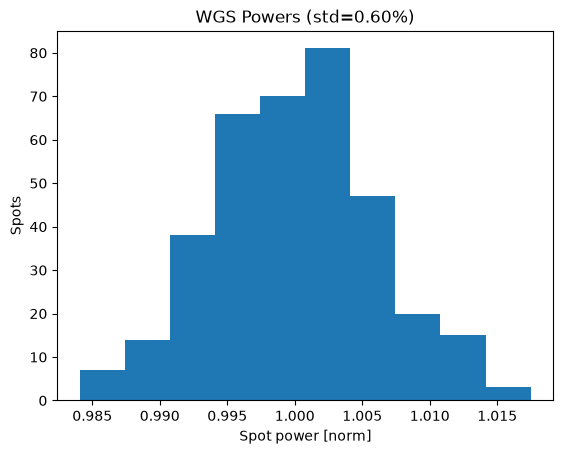

In [31]:
subimages = analysis.take(img, vectors=square, size=hologram.spot_integration_width_ij)

# Quantify uniformity.
powers = analysis.image_normalization(subimages)
powers_norm = powers / np.mean(powers)
powers_norm_std_wgs = np.std(powers_norm)

plt.hist(powers_norm)
plt.title("WGS Powers (std={:.2f}%)".format(powers_norm_std_wgs * 100))
plt.xlabel("Spot power [norm]")
plt.ylabel("Spots")
plt.show()

assert powers_norm_std_wgs < powers_norm_std_gs, "Make sure that the distribution got more uniform."

Much more uniform. With the `stat_groups` parameter, we also asked the `SpotHologram` to note statistics as the optimization proceeded. We can plot these with the `.plot_stats()` function.

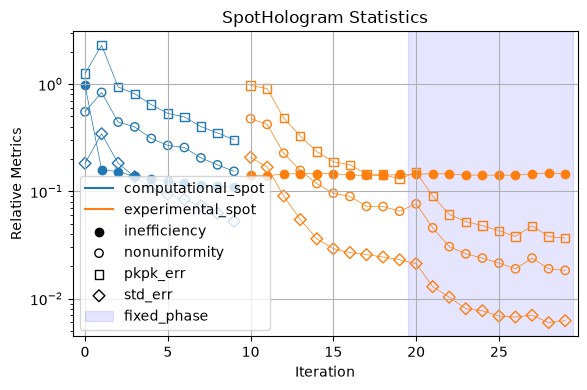

In [32]:
hologram.plot_stats();

This raises the question of what limits uniformity. In the case of this setup, it's tied to slow spot drift due to environmental fluctuations.
In a later tutorial, we'll see how to prove this using `FourierSLM`'s `.simulate` feature, which allows us to port an experimental setup into simulation to compare against theoretical performance. 

#### A Scattered Example

We can of course generate any arrangements of spots we'd like. For example, [Lloyd's Algorithm](https://en.wikipedia.org/wiki/Lloyd%27s_algorithm) iteratively generates an array of spots spread across a given space. In this case, we want to generate a cloud of points within the field of view of our camera.

In [33]:
lloyds_points = toolbox.lloyds_points(grid=fs.cam.shape, n_points=100, iterations=40)

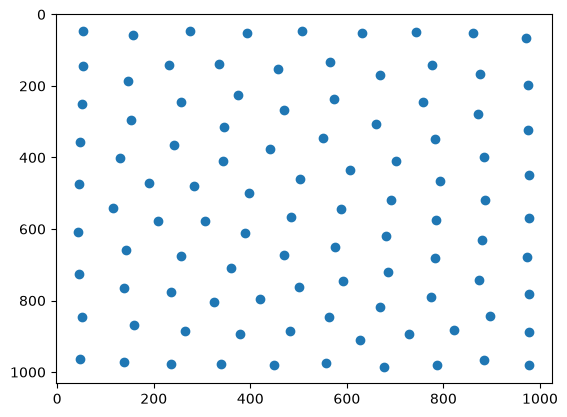

In [34]:
# Plot the points.
plt.scatter(lloyds_points[0, :], lloyds_points[1, :])
plt.gca().set_ylim(np.flip(plt.gca().get_ylim()))
plt.show()

We conduct the same process to optimize a hologram to generate this pattern.

In [35]:
# Set exposure to account for array size.
cam.set_exposure(single_spot_exposure_s * lloyds_points.shape[1])     
hologram = SpotHologram((2048, 2048), lloyds_points, basis='ij', cameraslm=fs)

# Precondition computationally.
hologram.optimize(
    'WGS-Leonardo',
    maxiter=10,
    feedback='computational_spot',
    stat_groups=['computational_spot']
)

# Hone the result with experimental feedback.
hologram.optimize(
    'WGS-Kim',
    maxiter=10,
    feedback='experimental_spot',
    stat_groups=['experimental_spot'],
)

[INF] 17:26:36 SpotHologram #3 Initialized SpotHologram.


100%|██████████| 10/10 [00:01<00:00,  5.33it/s]


Let's again take a look at what we generated.

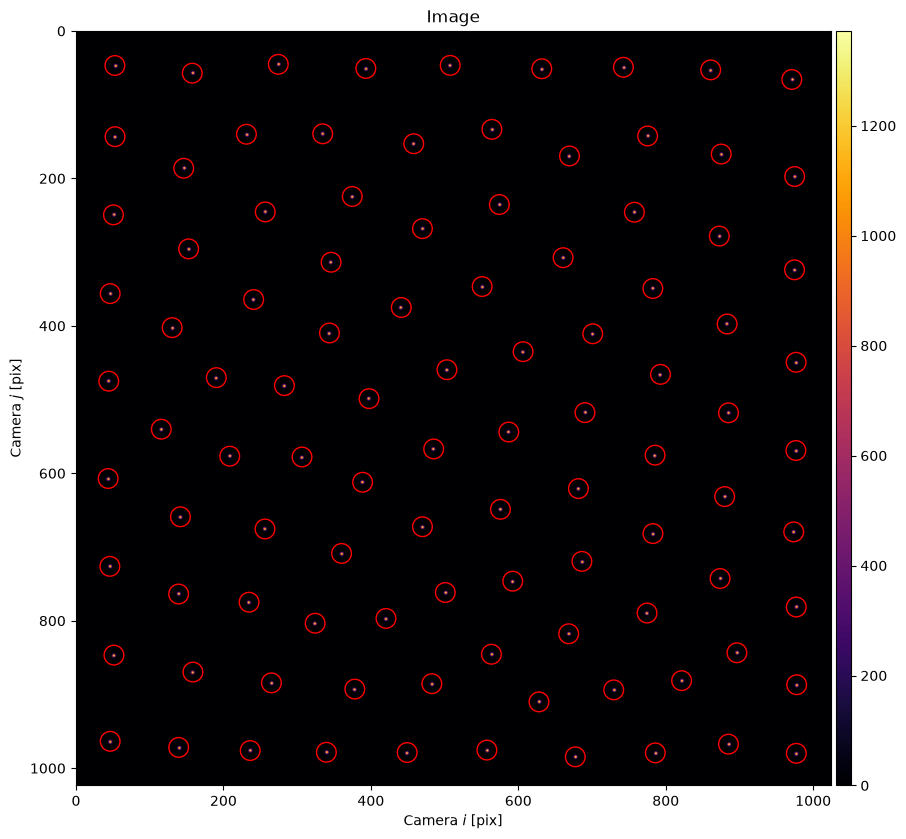

In [36]:
img = fs.cam.get_image()

plt.figure(figsize=(10, 10))
ax = fs.cam.plot(img)
ax.scatter(lloyds_points[0, :], lloyds_points[1, :], 200, facecolors='none', edgecolors='r')
plt.show()

Let's again take a look at the statistics. Patterns without crystalline order tend to converge faster than square arrays.

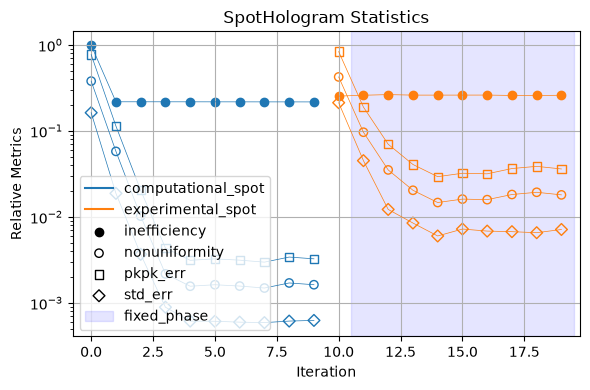

In [37]:
hologram.plot_stats();

#### Pictorial Holography

The spot holography we explored above is a subset of the general problem. In this section, we push further and look into forming images at desired positions in the camera's domain.

Let's start by loading a picture. We load an example helper function for this.

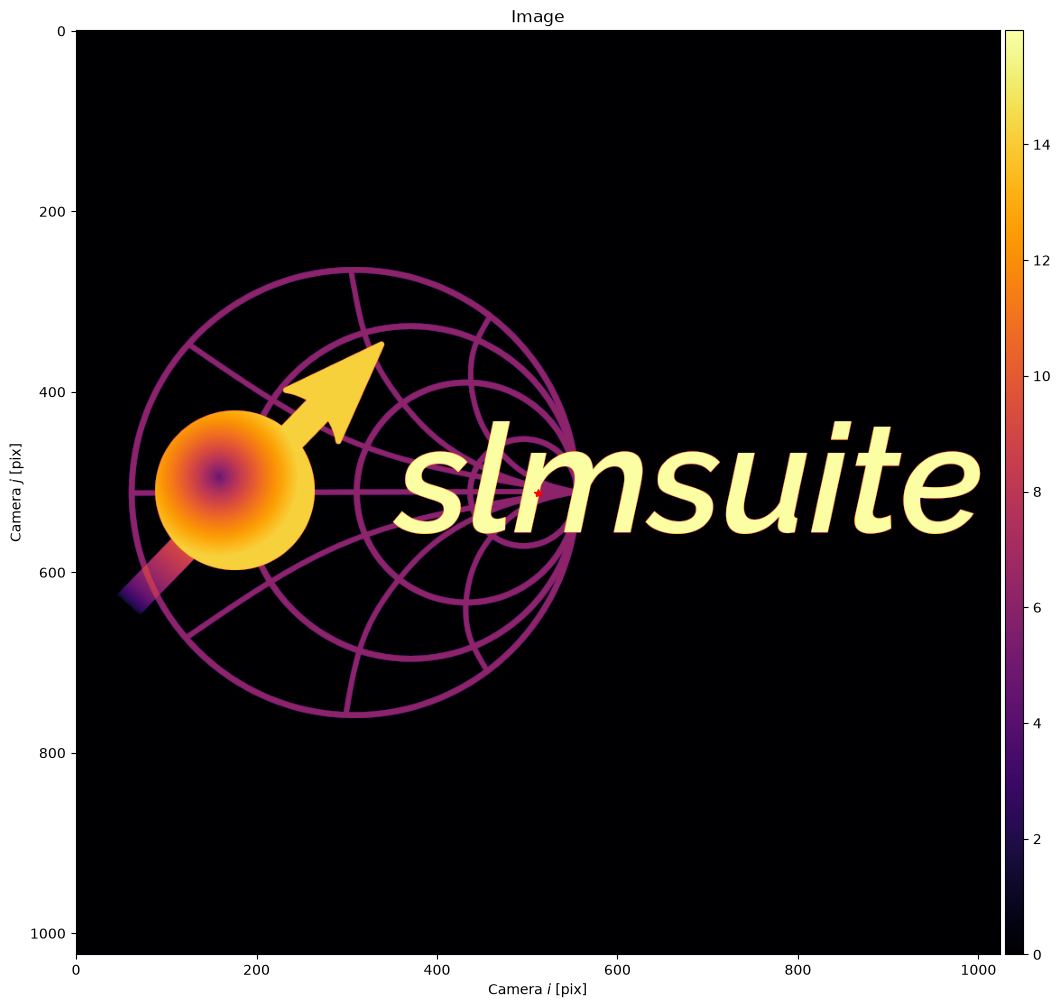

In [38]:
from slmsuite.holography.analysis.files import _load_image

path = os.path.join(os.getcwd(), '../../slmsuite/docs/source/static/slmsuite-small.png')

target_ij = _load_image(path, fs.cam.shape, angle=0, shift=(0, 0))

plt.figure(figsize=(16,12))
fs.cam.plot(target_ij)
plt.plot(target_ij.shape[1]/2, target_ij.shape[0]/2, 'r*');

Notice that the resulting image has the same shape as the camera. The goal is to replicate this pattern on the camera at the same position. We use similar syntax as before to initialize and optimize the hologram. This time we use a `FeedbackHologram`, which is actually the superclass of `SpotHologram`. `FeedbackHologram` is a subclass of `Hologram`, a class that only considers the abstract. `FeedbackHologram` has infrastructure to read in and interpret camera images. `SpotHologram` has infrastructure honed to optimize spot arrays. Let's take a look at our `FeedbackHologram`.

[INF] 17:26:39 FeedbackHologram Initialized FeedbackHologram.


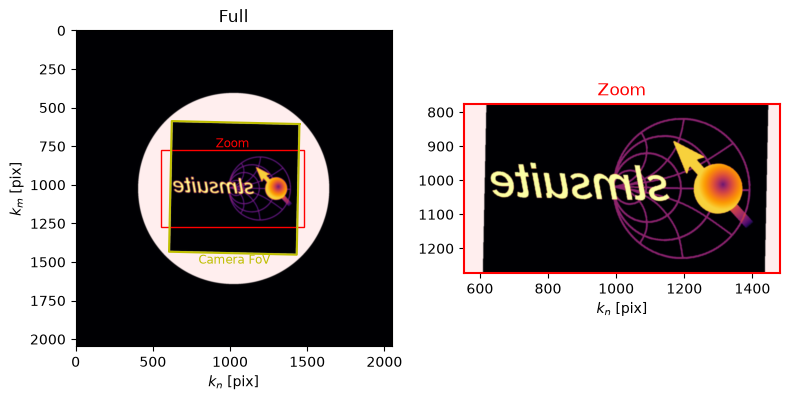

In [39]:
from slmsuite.holography.algorithms import FeedbackHologram

# null_region_radius_frac zeros power outside of a certain radius
# Here, we use it to prevent steering light to high k, which can impact our image
hologram = FeedbackHologram(shape=(2048, 2048),
                            target_ij=target_ij,
                            cameraslm=fs, 
                            null_region_radius_frac=.6);

limits = hologram.plot_farfield(hologram.target);
hologram.reset_phase(quadratic_phase=2)

We see how the image is imprinted upon the `"knm"` space in which the hologram is optimized. Now let's optimize it.

In [40]:
hologram.optimize(
    method="WGS-Leonardo",
    maxiter=10,
    feedback='computational',
    stat_groups=['computational']
)

100%|██████████| 10/10 [00:00<00:00, 68.28it/s]


We quickly plot the image, and see our hologram! It looks alright.

[INF] 17:26:41 FLIR Cam Autoexpose: 1.55e-01 s - 1995/4095
[INF] 17:26:46 FLIR Cam Autoexpose: 1.55e-01 s - 2099/4095


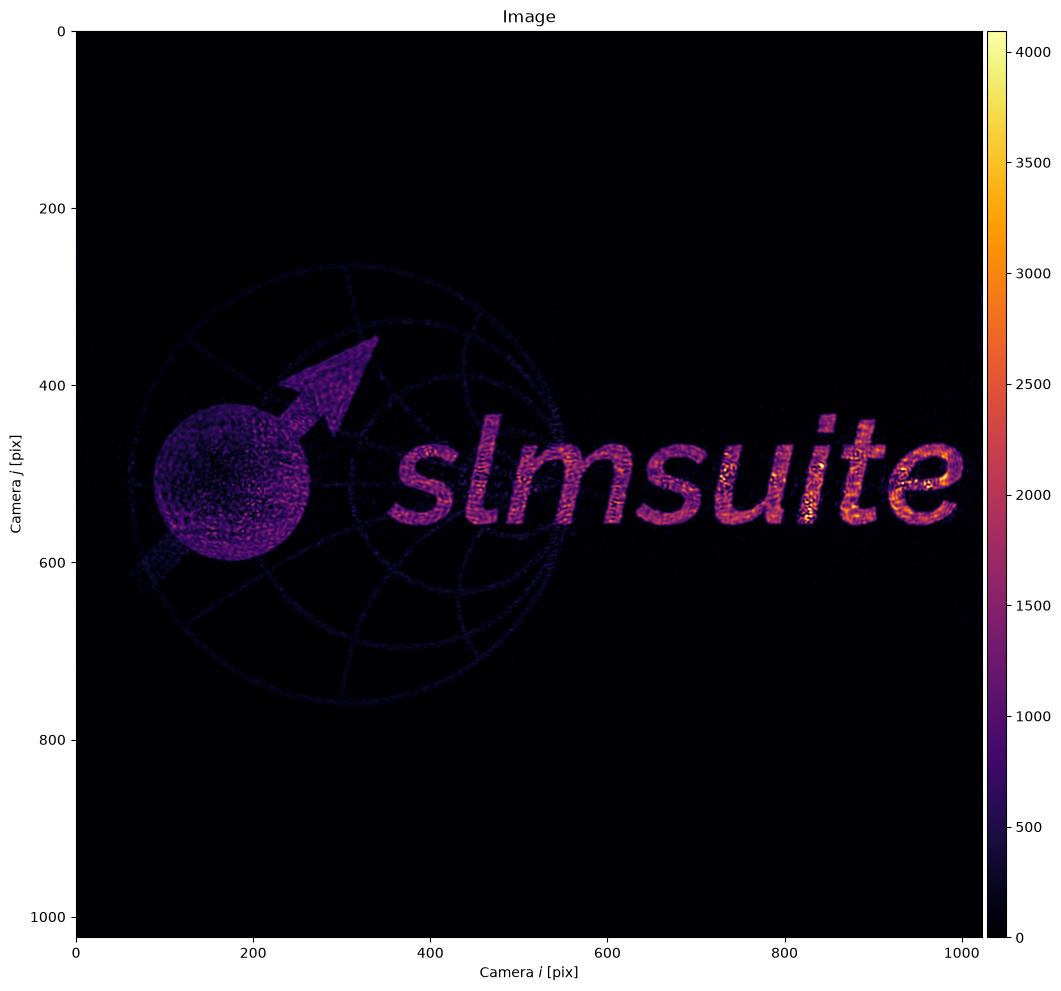

In [41]:
slm.set_phase(hologram.get_phase(), settle=True)

# Overexpose a bit for the image, then return for next optimization
cam.autoexpose(set_fraction=2)
plt.figure(figsize=(12,12))
cam.plot();
cam.autoexpose(set_fraction=0.8);

Let's look at the phase that produces this result:

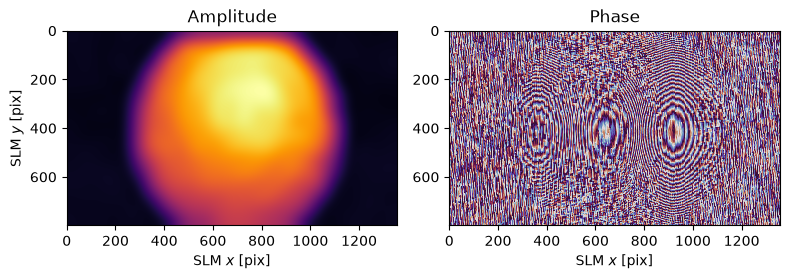

In [42]:
hologram.plot_nearfield()

We can also take a look at the hologram computationally, i.e. the expected result from Fourier-transforming the nearfield.
Notice that there is some power in the field (outside of our target pattern but inside of the region we designated to be truly zero via `null_region_radius_frac`), and we need to use the `limits` from the previous `.plot_farfield()` to get the zoom box to not be the whole domain.

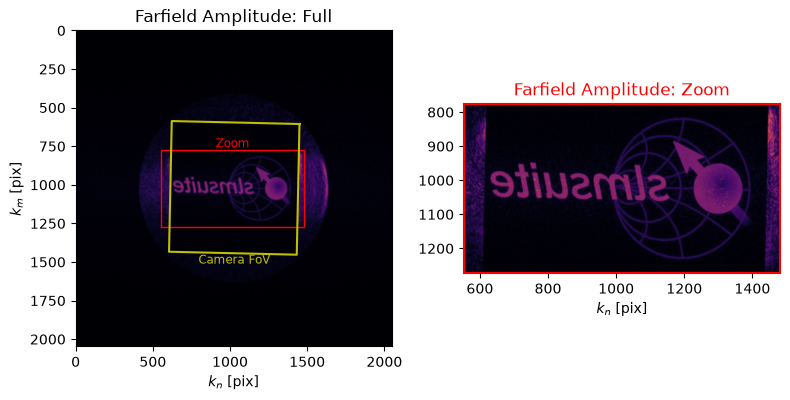

In [43]:
hologram.plot_farfield(limits=limits);

We can push this a bit further by again applying camera feedback, this time to the whole image.

In [44]:
hologram.optimize(
    method="WGS-Leonardo",
    maxiter=10,
    feedback='experimental',
    stat_groups=['computational', 'experimental'],
    blur_ij=1,
)

100%|██████████| 10/10 [00:09<00:00,  1.08it/s]


Now the hologram appears with much higher fidelity!

[INF] 17:26:59 FLIR Cam Autoexpose: 3.93e-01 s - 2038/4095


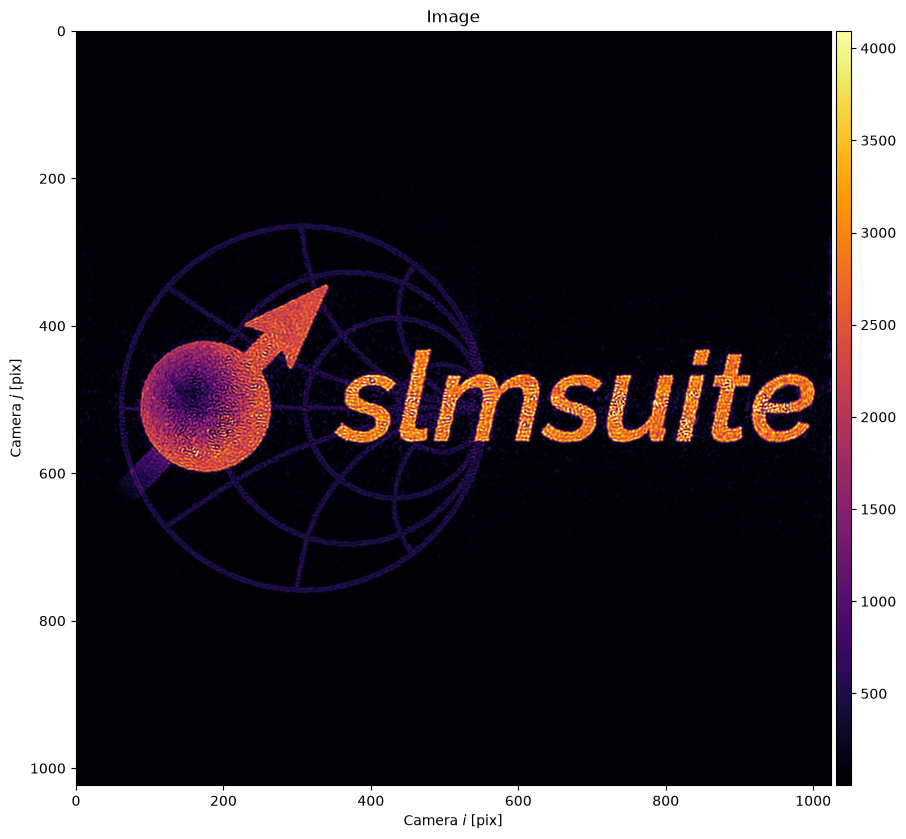

In [45]:
slm.set_phase(hologram.get_phase(), settle=True)
cam.autoexpose(set_fraction=2)        

plt.figure(figsize=(10, 10))
cam.plot();

We look forward to seeing what sort of holograms you'll make!

In [46]:
cam.close()
slm.close()